# SONICS Dataset Analysis
Minimalist, professional data analysis for the Master's Thesis.

## 1. Setup & Data Loading

In [ ]:
!uv pip install polars scikit-learn plotly nbformat

Audited 4 packages in 124ms


In [ ]:
import json
import os
from pathlib import Path
import soundfile as sf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.manifold import TSNE
from concurrent.futures import ThreadPoolExecutor

# Set minimalist professional theme for all plots
pio.templates.default = "plotly_white"


In [3]:
# Paths configuration
SONICS_BASE_PATH = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics")
DATA_BASE_PATH = SONICS_BASE_PATH / "all_data"
DATA = SONICS_BASE_PATH / "all_data_16k_mono"
METADATA = DATA_BASE_PATH / "metadata.json"
CACHE_METADATA = DATA_BASE_PATH / "metadata_cached_durations.csv"

embedds_path = SONICS_BASE_PATH / "preprocessed_16k_mono"
mert_path = embedds_path / "mert"
w2v_path = embedds_path / "wav2vec"


In [4]:
# Load original metadata
with open(METADATA, 'r') as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)
df_meta['duration'] = pd.to_numeric(df_meta['duration'], errors='coerce')
df_meta['spoof'] = df_meta['spoof'].str.capitalize()
df_meta['set'] = df_meta['set'].str.capitalize()


In [9]:
# Calculate or load real durations
# We cache this to a CSV so it doesn't take 1 minute every time you run the notebook.
if CACHE_METADATA.exists():
    df_meta = pd.read_csv(CACHE_METADATA)
    print("Loaded cached metadata with real durations.")
else:
    print("Calculating real audio durations (this will take ~1 minute)...")
    all_files = list(DATA.glob("*.flac"))
    
    def get_duration(filepath):
        try:
            info = sf.info(str(filepath))
            return filepath.name, info.duration
        except Exception:
            return filepath.name, np.nan
            
    durations = []
    with ThreadPoolExecutor(max_workers=16) as executor:
        for res in executor.map(get_duration, all_files):
            durations.append(res)
            
    df_real = pd.DataFrame(durations, columns=["filename", "real_duration_sec"])
    df_meta = pd.merge(df_meta, df_real, on="filename", how="inner")
    
    # Save to cache
    df_meta.to_csv(CACHE_METADATA, index=False)
    print("Durations calculated and cached.")

# Calculate total hours
total_bona_hours = df_meta[df_meta['spoof'] == 'Bonafide']['real_duration_sec'].sum() / 3600
total_fake_hours = df_meta[df_meta['spoof'] == 'Deepfake']['real_duration_sec'].sum() / 3600

print(f"Total Bonafide Audio: {total_bona_hours:.2f} hours")
print(f"Total Deepfake Audio: {total_fake_hours:.2f} hours")
print(f"Total Dataset Audio: {total_bona_hours + total_fake_hours:.2f} hours")


Loaded cached metadata with real durations.
Total Bonafide Audio: 2709.34 hours
Total Deepfake Audio: 1969.27 hours
Total Dataset Audio: 4678.62 hours


/net/afscra/people/plgjedrzejkusnierz/slurm_jobdir/20521544/tmp.ac0787/ipykernel_303665/3371521904.py:4: DtypeWarning: Columns (6,7,8,9,10,11,13,14,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(CACHE_METADATA)


## 2. Dataset Stratification
A professional bar chart is highly preferred over a pie chart for academic papers. It allows for precise comparison between sets.

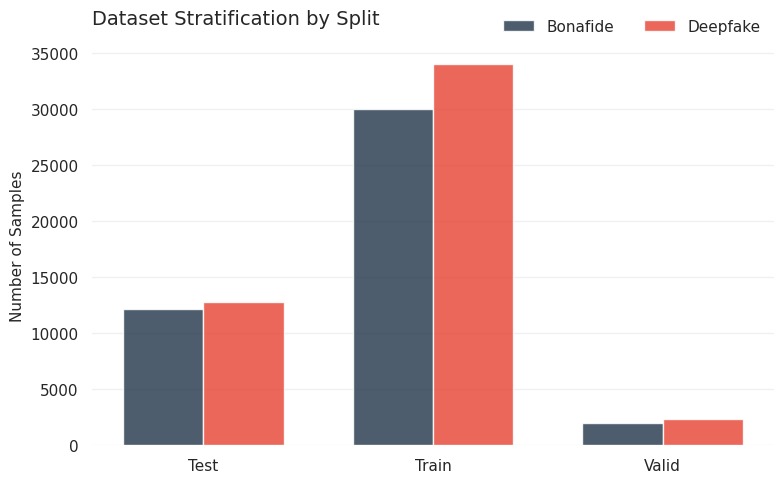

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Przygotowanie danych (Twoja agregacja)
strat_data = df_meta.groupby(['set', 'spoof']).size().reset_index(name='count')

# Wyciągamy unikalne splity (np. Train, Test, Valid)
splits = strat_data['set'].unique()

# Pobieramy wartości dla obu klas, dbając o kolejność splitów
bonafide_counts = [strat_data[(strat_data['set'] == s) & (strat_data['spoof'] == 'Bonafide')]['count'].values[0] for s in splits]
deepfake_counts = [strat_data[(strat_data['set'] == s) & (strat_data['spoof'] == 'Deepfake')]['count'].values[0] for s in splits]

# 2. Ustawienia pozycji słupków obok siebie
x = np.arange(len(splits))  # Pozycje dla grup
width = 0.35                # Szerokość pojedynczego słupka

# 3. Rysowanie wykresu
fig, ax = plt.subplots(figsize=(8, 5))

# Słupki obok siebie (stąd przesunięcia -width/2 i +width/2)
rects1 = ax.bar(x - width/2, bonafide_counts, width, color='#2E4053', alpha=0.85, label='Bonafide')
rects2 = ax.bar(x + width/2, deepfake_counts, width, color='#E74C3C', alpha=0.85, label='Deepfake')

# 4. Identyczna stylizacja (brak ramek, lekka pozioma siatka)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.grid(True, color='#f0f0f0', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

# Ustawienia osi X
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11)

# Podpisy i legenda na górze (spójne z poprzednim wykresem)
ax.set_title('Dataset Stratification by Split', fontsize=14, pad=15, loc='left')
ax.set_ylabel('Number of Samples', fontsize=11)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 1.1), ncol=2)

plt.tight_layout()

# 5. Zapis wektorowy do magisterki
plt.savefig('dataset_stratification.pdf', format='pdf', bbox_inches='tight', dpi=300)
# plt.savefig('dataset_stratification.svg', format='svg', bbox_inches='tight') # ewentualnie do Worda
plt.show()
plt.close()

In [6]:
df_meta.columns

Index(['dataset', 'filename', 'filepath', 'set', 'duration', 'bit_rate',
       'topic', 'style', 'label', 'lyrics', 'algorithm', 'mood', 'spoof',
       'original_filename', 'youtube_id', 'year', 'artist_overlap', 'title',
       'singer', 'url'],
      dtype='object')

In [7]:
df_meta[df_meta['set'] == "Train"]['algorithm'].value_counts()

algorithm
chirp-v3.5    17195
udio-120s     16828
Name: count, dtype: int64

In [30]:
df_meta[df_meta['algorithm'] == "chirp-v3.5"]['set'].value_counts()

set
Train    17195
Test      1590
Valid      272
Name: count, dtype: int64

## 3. Generative Algorithms
Analyzing the distribution of Deepfake generation algorithms. Showing this per split proves that the generation methods are well-stratified across Train/Valid/Test.

In [18]:
!uv pip install altair

⠙ Resolving dependencies...                                                     

Resolved 11 packages in 299ms                                        
Prepared 1 package in 107ms                                              
Installed 1 package in 23ms                                 
 + altair==6.2.1


In [37]:
import altair as alt

chart = alt.Chart(algo_data).mark_bar(cornerRadiusTopRight=3, cornerRadiusBottomRight=3).encode(
    y=alt.Y('algorithm:N', sort='-x', title=None), 
    x=alt.X('count:Q', title=None),
    color=alt.Color('set:N', sort=['Train', 'Test', 'Valid']),
    order=alt.Order('set', sort='ascending'),
    tooltip=['algorithm', 'set', 'count']
).properties(
    title='Algorithms Distribution',
    width=450,
    height=100 # Zmniejszając tę wartość, "bijesz" wykres w pionie
).configure_view(
    strokeWidth=0
).configure_axis(
    grid=False
)

chart.display()

alt.Chart(...)

## 4. Audio Duration Distribution
Overlaid histograms with transparency (opacity) and logarithmic Y-axis. Plotly handles empty bins and logarithmic scales much better than Seaborn.

In [51]:
df_meta.columns

Index(['dataset', 'filename', 'filepath', 'set', 'duration', 'bit_rate',
       'topic', 'style', 'label', 'lyrics', 'algorithm', 'mood', 'spoof',
       'original_filename', 'youtube_id', 'year', 'artist_overlap', 'title',
       'singer', 'url', 'real_duration_sec'],
      dtype='object')

In [ ]:
df_meta['mood'].value_counts()

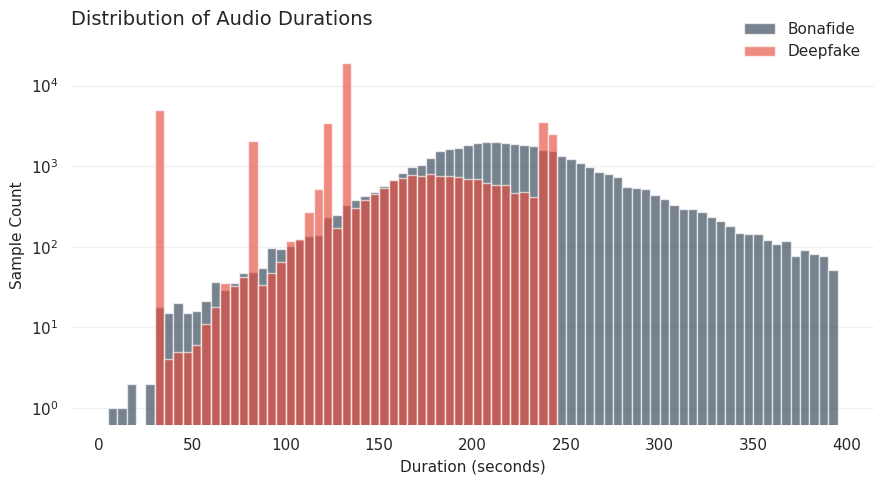

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtrowanie danych (to już znasz)
df_plot = df_meta[df_meta['real_duration_sec'] <= 420]

bonafide = df_plot[df_plot['spoof'] == 'Bonafide']['real_duration_sec']
deepfake = df_plot[df_plot['spoof'] == 'Deepfake']['real_duration_sec']

# 2. Definiujemy koszyki (szerokość 5 sekund)
bins = np.arange(0, 405, 5)

# 3. RĘCZNIE przeliczamy histogramy w Pythonie (to trwa ułamek sekundy)
counts_bf, edges = np.histogram(bonafide, bins=bins)
counts_df, _     = np.histogram(deepfake, bins=bins)

# Środek każdego słupka na wykresie
bin_centers = (edges[:-1] + edges[1:]) / 2

# KLUCZOWY KROK: Zamieniamy zera na NaN, żeby skala logarytmiczna ich nie popsuła
counts_bf = counts_bf.astype(float)
counts_df = counts_df.astype(float)
counts_bf[counts_bf == 0] = np.nan
counts_df[counts_df == 0] = np.nan

# 4. Rysowanie wykresu
fig, ax = plt.subplots(figsize=(9, 5))

# Rysujemy słupki o stałej szerokości 5
ax.bar(bin_centers, counts_bf, width=5, alpha=0.65, color='#2E4053', label='Bonafide')
ax.bar(bin_centers, counts_df, width=5, alpha=0.65, color='#E74C3C', label='Deepfake')

# Bezpieczne włączenie skali logarytmicznej (zera już nie istnieją)
ax.set_yscale('log')

# 5. Identyczna stylizacja jak w Altair (brak ramek, lekka siatka)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.grid(True, color='#f0f0f0', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

# Podpisy i legenda na górze
ax.set_title("Distribution of Audio Durations", fontsize=14, pad=15, loc='left')
ax.set_xlabel("Duration (seconds)", fontsize=11)
ax.set_ylabel("Sample Count", fontsize=11)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 1.1))

plt.tight_layout()
plt.savefig('histogram_magisterka.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

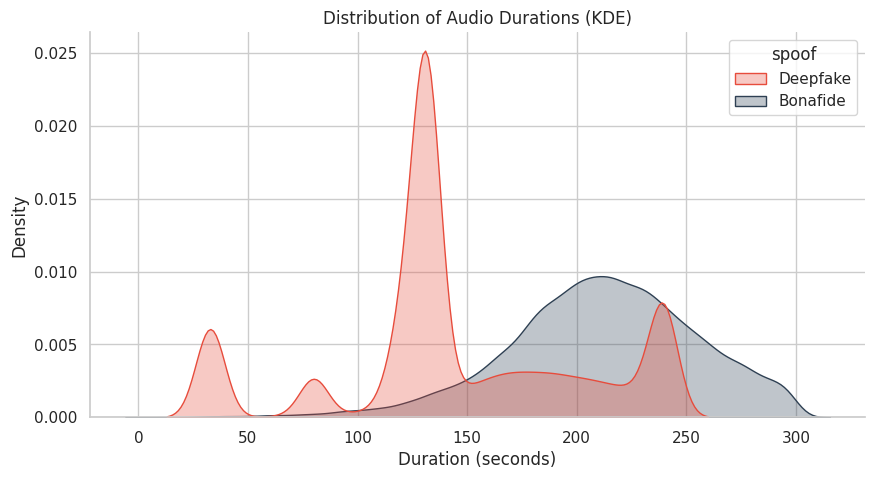

In [49]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df_plot, 
    x="real_duration_sec", 
    hue="spoof", 
    fill=True, 
    common_norm=False, 
    palette={'Bonafide': '#2E4053', 'Deepfake': '#E74C3C'},
    alpha=0.3
)
plt.title('Distribution of Audio Durations (KDE)')
plt.xlabel('Duration (seconds)')
sns.despine() # Usuwa zbędne ramki
plt.show()

## 5. Embeddings & EDA
Scaffolding for t-SNE visualization and Data Leakage checks.

In [ ]:
def plot_tsne_plotly(features_2d, labels, title="t-SNE Embeddings Visualization"):
    '''Professional t-SNE plot using Plotly.'''
    df_tsne = pd.DataFrame({
        'Dim 1': features_2d[:, 0],
        'Dim 2': features_2d[:, 1],
        'Class': labels
    })
    
    fig = px.scatter(
        df_tsne, x='Dim 1', y='Dim 2', color='Class',
        title=title,
        color_discrete_map={'Bonafide': '#2E4053', 'Deepfake': '#E74C3C'},
        opacity=0.6
    )
    
    fig.update_layout(
        font=dict(family="Arial", size=14),
        plot_bgcolor='white',
        margin=dict(t=60, b=40, l=40, r=40)
    )
    
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False)
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False)
    
    fig.show()

In [ ]:
def check_data_leakage(df_features, label_col='spoof'):
    '''Checks for suspiciously high feature mean differences (Data Leakage).'''
    feature_cols = [c for c in df_features.columns if c != label_col]
    
    means_bona = df_features[df_features[label_col] == 'Bonafide'][feature_cols].mean()
    means_fake = df_features[df_features[label_col] == 'Deepfake'][feature_cols].mean()
    
    diffs = (means_bona - means_fake).abs().sort_values(ascending=False)
    
    print("Top 5 Mean Differences across single features:")
    print(diffs.head(5))
    
    if diffs.iloc[0] > 10.0:
        print("\n[WARNING] Potential Data Leakage detected on a single feature!")
    else:
        print("\n[OK] No obvious single-feature anomalies detected.")